# ANALITICA DE DATOS CON INTELIGENCIA ARTIFICIAL

# RNN - LSTM

**Universidad de los Andes**

2025

---


Juan Carlos Vega, M.Sc.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
!pip install tensorflow

In [4]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import History

Confirmamos que estamos utilizando el GPU

In [5]:
# Check that TensorFlow is using the GPU
print(tf.test.gpu_device_name())

/device:GPU:0


## Deep Learning

Este código define una red neuronal LSTM para predecir la velocidad del viento en días futuros. Primero, se carga un conjunto de datos en formato CSV con información histórica de velocidad del viento. Se define una función para preparar los datos y dividirlos en conjuntos de entrenamiento, validación y prueba.

Luego, se construye la red LSTM utilizando la biblioteca Keras de TensorFlow. La red consta de una capa de entrada, una capa LSTM con 64 unidades, una capa densa con activación ReLU y otra capa densa de salida con activación lineal. También se define un punto de control para guardar el modelo que tiene mejor rendimiento en validación durante el entrenamiento.

Se compila la red utilizando la función de pérdida Mean Squared Error, el optimizador Adam y la métrica de evaluación Root Mean Squared Error. Se ajusta la red con el conjunto de entrenamiento y se evalúa su rendimiento en los conjuntos de validación y prueba.

Finalmente, se generan predicciones para los conjuntos de entrenamiento, validación y prueba, y se comparan con los valores reales para evaluar el rendimiento del modelo.

## Carga de datos:
El código comienza cargando los datos de velocidad del viento de un archivo csv y eliminando las columnas innecesarias.

In [6]:
windData = pd.read_csv('/content/gdrive/MyDrive/SENSORES_REMOTOS/DATASETS/Maicao_proyectoAlpha.csv', skiprows = 3, index_col = 'time', parse_dates = True)
windData.head()

,local_time,electricity,wind_speed
time,,,
2019-01-01 00:00:00,2018-12-31 19:00,190549.284,11.983
2019-01-01 01:00:00,2018-12-31 20:00,188464.474,11.789
2019-01-01 02:00:00,2018-12-31 21:00,188737.589,11.815
2019-01-01 03:00:00,2018-12-31 22:00,188978.941,11.837
2019-01-01 04:00:00,2018-12-31 23:00,190802.053,12.005


In [ ]:
windData.drop(columns=['local_time', 'electricity'], inplace=True)

windData.head()

,wind_speed
time,
2019-01-01 00:00:00,13.742
2019-01-01 01:00:00,13.783
2019-01-01 02:00:00,13.515
2019-01-01 03:00:00,13.327
2019-01-01 04:00:00,13.341


In [ ]:
windData.tail()

,wind_speed
time,
2019-12-31 19:00:00,7.554
2019-12-31 20:00:00,7.904
2019-12-31 21:00:00,8.601
2019-12-31 22:00:00,9.193
2019-12-31 23:00:00,9.256


In [ ]:
windData.dtypes

,0
wind_speed,float64


---

Imaginemos que tenemos la siguiente serie de tiempo:

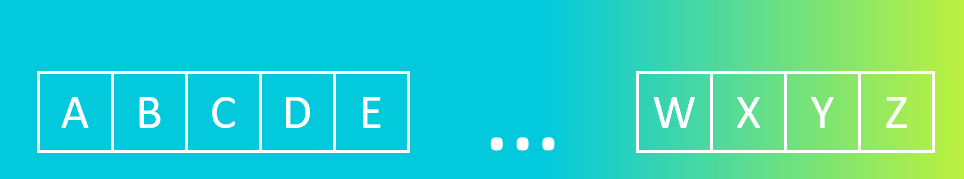

Por ejemplo, podemos tomar los primeros 3 valores como entrada (input), para predecir el siguiente valor (output):

In [ ]:
n_input = 3 # dias
n_feature = 1 # dia

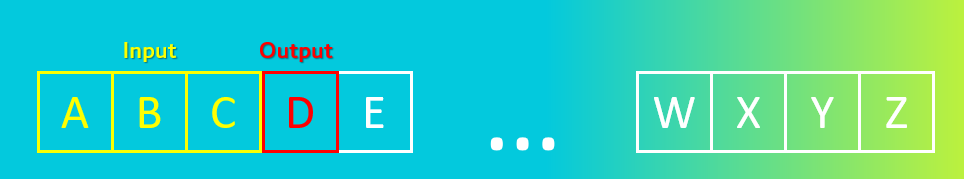

Y asi seguir consecutivamente:

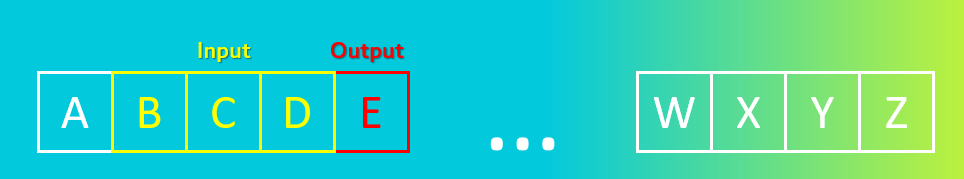

Hasta llegar al ultimo valor de la secuencia:

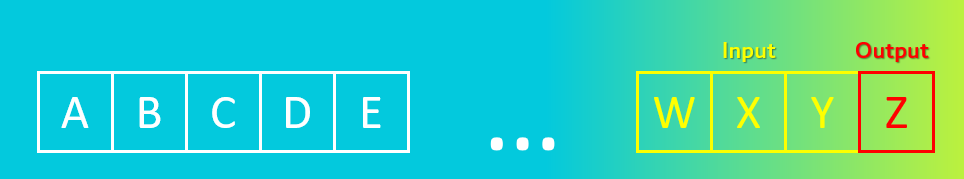

Vamos a crear un arreglo de datos que tenga la siguiente forma:
```python
    Input      Output
      X           y
[1, 2, 3, 4, 5]  [6]
[2, 3, 4, 5, 6]  [7]
...
[5, 6, 7, 8, 9]  [10]
```

Para esto, vamos a generar una funcion que convierta nuestros datos a X y y, donde los parametros de entrada es el set de datos, y la ventana de valores deseada:

In [ ]:
def df_X_y (df, window_size):
    # Convertimos set de datos de pandas a numpy
    df_np = df.to_numpy()
    X = []
    y = []

    for i in range(len(df_np)-window_size):
        row = [[a] for a in df_np[i:i+window_size]]
        X.append(row)
        true = df_np[i+window_size]
        y.append(true)
    return np.array(X), np.array(y)


In [ ]:
window_size = 5

In [ ]:
X, y = df_X_y(windData['wind_speed'], window_size)

In [ ]:
X

array([[[13.742],
        [13.783],
        [13.515],
        [13.327],
        [13.341]],

       [[13.783],
        [13.515],
        [13.327],
        [13.341],
        [13.335]],

       [[13.515],
        [13.327],
        [13.341],
        [13.335],
        [13.481]],

       ...,

       [[ 8.059],
        [ 7.72 ],
        [ 7.487],
        [ 7.554],
        [ 7.904]],

       [[ 7.72 ],
        [ 7.487],
        [ 7.554],
        [ 7.904],
        [ 8.601]],

       [[ 7.487],
        [ 7.554],
        [ 7.904],
        [ 8.601],
        [ 9.193]]])

In [ ]:
y

array([13.335, 13.481, 13.744, ...,  8.601,  9.193,  9.256])

In [ ]:
X.shape

(8755, 5, 1)

In [ ]:
y.shape

(8755,)

In [ ]:
windData['wind_speed'].shape

(8760,)

## División de datos en entrenamiento, validación y prueba:
Dividimos los datos en set de prueba (2000) y entrenamiento (6000) y validacion (760)

In [ ]:
X_train, y_train = X[:6000], y[:6000]
X_test, y_test = X[6000:8000], y[6000:8000]
X_val, y_val = X[8000:], y[8000:]

In [ ]:
print('X_train: ', X_train.shape)
print('y_train: ', y_train.shape)
print('-------')
print('X_test: ', X_test.shape)
print('y_test: ', y_test.shape)
print('-------')
print('X_val: ', X_val.shape)
print('y_val: ', y_val.shape)

X_train:  (6000, 5, 1)
y_train:  (6000,)
-------
X_test:  (2000, 5, 1)
y_test:  (2000,)
-------
X_val:  (755, 5, 1)
y_val:  (755,)


---

### Definición de la red neuronal LSTM:
Se define un modelo de red neuronal LSTM que consta de una capa de entrada, una capa LSTM, una capa densa con función de activación relu y otra capa densa con función de activación lineal.

In [ ]:
model1 = Sequential() # Secuencial significa que la Red Neuronal tiene varias capas
model1.add(InputLayer((window_size, 1))) # Cual es el tamano de los datos de entrada
model1.add(LSTM(64)) # Capa de tipo LSTM
model1.add(Dense(8, 'relu')) # Densa quiere decir que se conecten todas las neuronas y utilizamos una funcion de activacion tipo ReLu
model1.add(Dense(1, 'linear'))

In [ ]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 8)                   │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

### Compilación del modelo y entrenamiento:
Se compila el modelo definiendo la función de pérdida, el optimizador y las métricas. Luego se entrena el modelo utilizando los datos de entrenamiento y validación.

In [ ]:
# Obtener historial de entrenamiento del modelo
history = History()

In [ ]:
# Aqui guardamos el modelo como un archivo independiente

cp1 = ModelCheckpoint('/content/gdrive/MyDrive/IA Energias Renovables | UniAndes/Notebooks/Sesion 3b (Mar, 9, 2023)/model1.keras', save_best_only=True)
model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.001), metrics=[RootMeanSquaredError()])

In [ ]:
# Fit the model
with tf.device('/device:GPU:0'):  # Specify the GPU device to use
    history = model1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, callbacks=[cp1]) # cp = check point

# model1 = load_model('/content/gdrive/MyDrive/IA Energias Renovables | UniAndes/Notebooks/Sesion 3a (Mar, 7, 2023)/model1/')

# model1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, callbacks=[cp1])

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 55.7641 - root_mean_squared_error: 7.2091 - val_loss: 0.6571 - val_root_mean_squared_error: 0.8106
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.4512 - root_mean_squared_error: 0.6672 - val_loss: 0.2090 - val_root_mean_squared_error: 0.4572
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2358 - root_mean_squared_error: 0.4853 - val_loss: 0.1649 - val_root_mean_squared_error: 0.4061
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1792 - root_mean_squared_error: 0.4231 - val_loss: 0.1850 - val_root_mean_squared_error: 0.4301
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1343 - root_mean_squared_error: 0.3664 - val_loss: 0.0949 - val_root_mean_squared_error: 0.3080
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1063 - root_mean_squared_error: 0.3259 - val_loss: 0.0785 - val_root_mean_squared_error: 0.2802
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

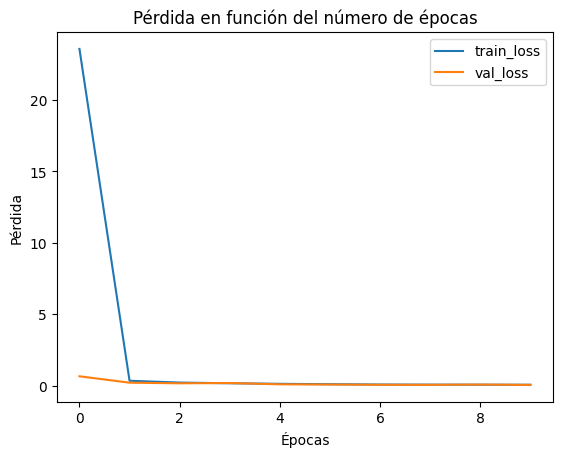

In [ ]:
# Plot the loss history
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Pérdida en función del número de épocas')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

### Carga del modelo guardado y predicción:
Finalmente, se carga el modelo guardado y se realizan las predicciones para los datos de entrenamiento, validación y prueba.

In [ ]:
# Cargamos modelo

model1 = load_model('/content/gdrive/MyDrive/IA Energias Renovables | UniAndes/Notebooks/Sesion 3b (Mar, 9, 2023)/model1.keras')

In [ ]:
train_predictions = model1.predict(X_train).flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train})
train_results

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Train Predictions,Actuals
0,13.305330,13.335
1,13.286554,13.481
2,13.491798,13.744
3,13.787998,14.117
4,14.179329,14.295
...,...,...
5995,8.438668,8.103
5996,7.840748,8.018
5997,7.541432,7.849
5998,7.566530,7.628


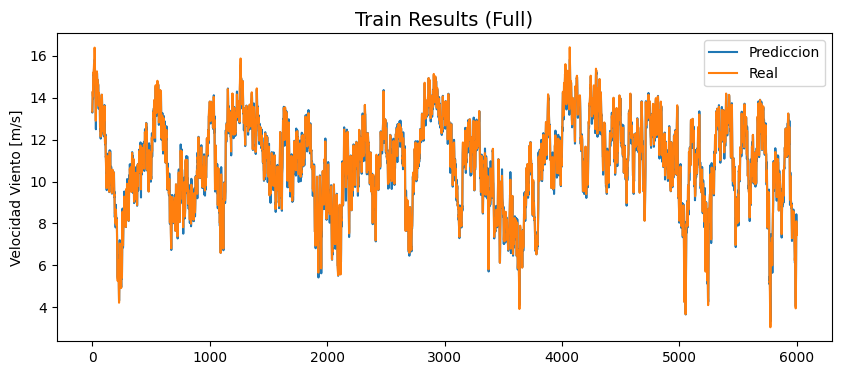

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Train Results (Full)', fontsize = 14)
plt.plot(train_results['Train Predictions'], label = 'Prediccion')
plt.plot(train_results['Actuals'], label = 'Real')
plt.ylabel('Velocidad Viento [m/s]')
plt.legend()

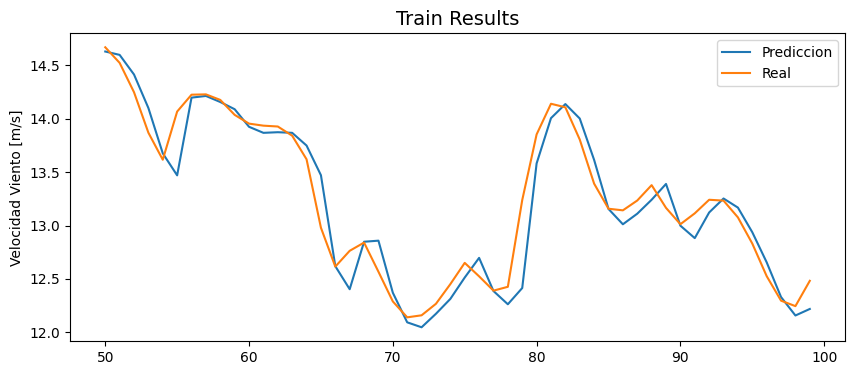

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Train Results', fontsize = 14)
plt.plot(train_results['Train Predictions'][50:100], label = 'Prediccion')
plt.plot(train_results['Actuals'][50:100], label = 'Real')
plt.ylabel('Velocidad Viento [m/s]')
plt.legend()

In [ ]:
test_predictions = model1.predict(X_test).flatten()
test_results = pd.DataFrame(data={'Test Predictions':test_predictions, 'Actuals':y_test})
test_results

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


,Test Predictions,Actuals
0,7.353416,7.243
1,7.142052,6.995
2,6.872064,6.783
3,6.690536,6.576
4,6.498555,6.545
...,...,...
1995,6.957827,7.096
1996,7.101141,6.870
1997,6.699930,6.367
1998,6.049694,5.921


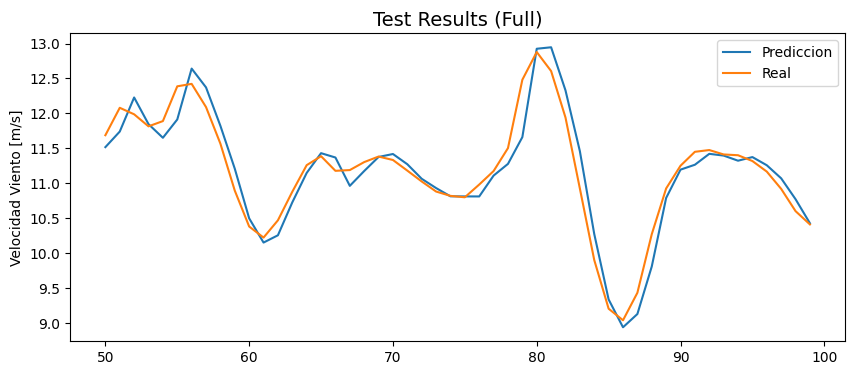

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Test Results (Full)', fontsize = 14)
plt.plot(test_results['Test Predictions'][50:100], label = 'Prediccion')
plt.plot(test_results['Actuals'][50:100], label = 'Real')
plt.ylabel('Velocidad Viento [m/s]')
plt.legend()

In [ ]:
val_predictions = model1.predict(X_val).flatten()
val_results = pd.DataFrame(data={'Val Predictions':val_predictions, 'Actuals':y_val})
val_results

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Val Predictions,Actuals
0,5.715013,5.574
1,5.631815,5.298
2,5.267223,5.078
3,5.065535,4.939
4,4.998353,4.863
...,...,...
750,7.411678,7.554
751,7.657730,7.904
752,8.149821,8.601
753,8.993229,9.193


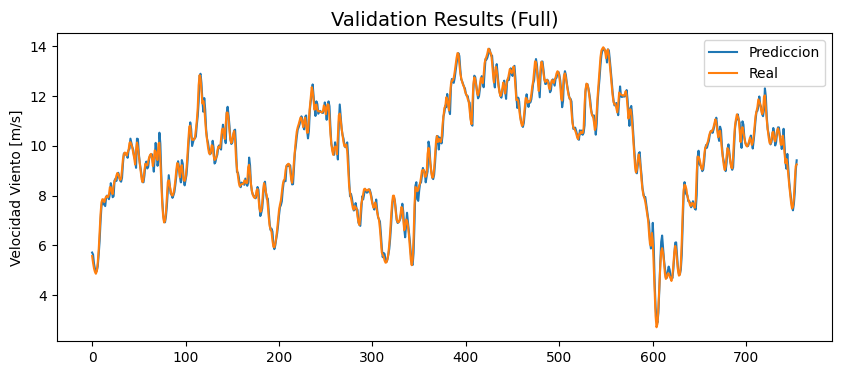

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Validation Results (Full)', fontsize = 14)
plt.plot(val_results['Val Predictions'], label = 'Prediccion')
plt.plot(val_results['Actuals'], label = 'Real')
plt.ylabel('Velocidad Viento [m/s]')
plt.legend()

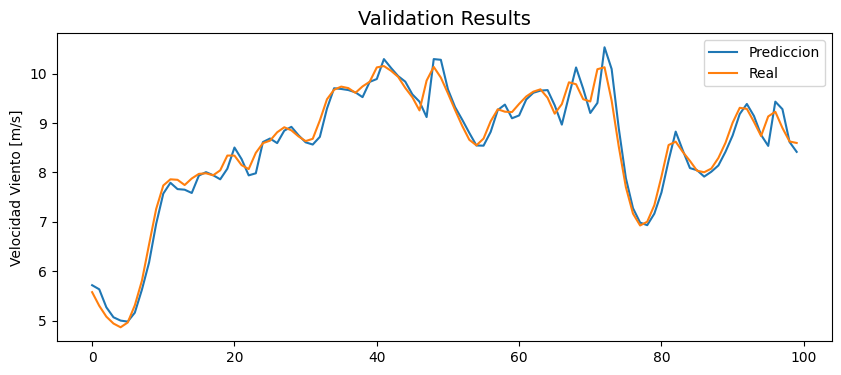

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Validation Results', fontsize = 14)
plt.plot(val_results['Val Predictions'][:100], label = 'Prediccion')
plt.plot(val_results['Actuals'][:100], label = 'Real')
plt.ylabel('Velocidad Viento [m/s]')
plt.legend()

---

In [ ]:
# Calculate RMSE and MSE for train, validation and test datasets
train_loss, train_rmse = model1.evaluate(X_train, y_train, verbose=0)
val_loss, val_rmse = model1.evaluate(X_val, y_val, verbose=0)
test_loss, test_rmse = model1.evaluate(X_test, y_test, verbose=0)

In [ ]:
print(f'Train RMSE: {train_rmse:.2f}')
print(f'Train MSE: {train_loss:.2f}')
print(f'Validation RMSE: {val_rmse:.2f}')
print(f'Validation MSE: {val_loss:.2f}')
print(f'Test RMSE: {test_rmse:.2f}')
print(f'Test MSE: {test_loss:.2f}')

Train RMSE: 0.24
Train MSE: 0.06
Validation RMSE: 0.23
Validation MSE: 0.05
Test RMSE: 0.29
Test MSE: 0.08


---

## Prediccion

Ahora podemos realizar la prediccion de las proximos 100 horas de velocidad de viento, utilizando el modelo:

In [ ]:
diasPrediccion = 100 # horas

In [ ]:
# Make predictions
preds = []
last_window = X[-1]
for i in range(diasPrediccion):
    next_pred = model1.predict(last_window.reshape((1, window_size, 1)))[0][0]
    preds.append(next_pred)
    last_window = np.vstack((last_window[1:], next_pred))

# Create a pandas dataframe with the predictions and the corresponding dates
index = pd.date_range(start=windData.index[-1], periods=diasPrediccion+1, freq='H')[1:]
preds_df = pd.DataFrame({'Predictions': preds}, index=index)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━

<ipython-input-39-0d130e62ff13>:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  index = pd.date_range(start=windData.index[-1], periods=diasPrediccion+1, freq='H')[1:]


In [ ]:
# Concatenate the original time series data with the predictions
full_data = pd.concat([windData['wind_speed'], preds_df])

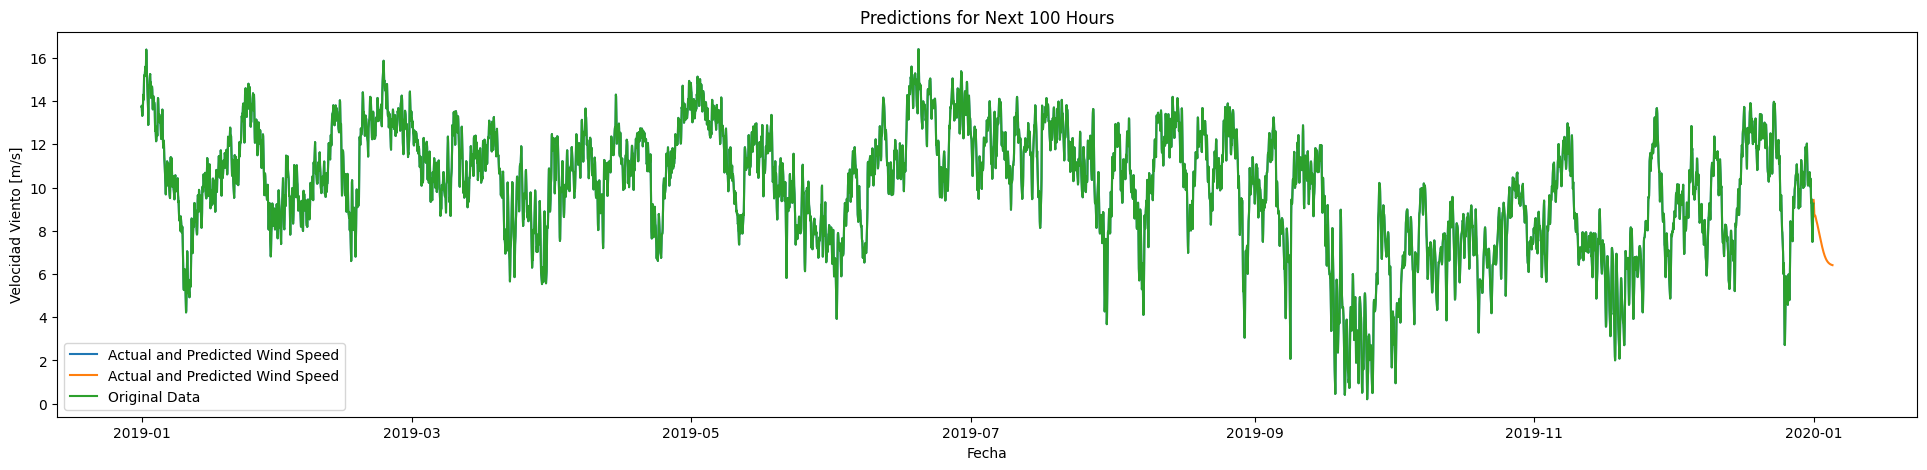

In [ ]:
# Plot the results
plt.figure(figsize=(24,5))
plt.plot(full_data.index, full_data, label='Actual and Predicted Wind Speed')
plt.plot(windData.index, windData['wind_speed'], label='Original Data')
plt.xlabel('Fecha')
plt.ylabel('Velocidad Viento [m/s]')
plt.title('Predictions for Next 100 Hours')
plt.legend()
plt.show()

El resultado del modelo se puede considerar correcto, ya que se ajusta a promedio de los datos. Sin embargo, nosotros queremos aumentar el nivel de prediccion. Por lo tanto, en el siguiente modelo, vamos a modificar:
* Ventana (window_size) (24)
* Numero de epocas de entrenamiento (20)

---

Que tal si ahora repetimos el ejercicio, pero en vez de tomar 5 mediciones, aumentamos a 24 mediciones (lo cual corresponde a las 24 horas del dia).

Para esto, modificamos la tamano de la ventana a 24

In [ ]:
window_size = 24

In [ ]:
X, y = df_X_y(windData['wind_speed'], window_size)

Mantenemos la division en el set de prueba (6000), entrenamiento (2000) y validacion (760)

In [ ]:
X_train, y_train = X[:6000], y[:6000]
X_test, y_test = X[6000:8000], y[6000:8000]
X_val, y_val = X[8000:], y[8000:]

---

### Definición un nuevo modelo LSTM:


In [ ]:
model2 = Sequential()
model2.add(InputLayer((window_size, 1)))
model2.add(LSTM(64))
model2.add(Dense(8, 'relu'))
model2.add(Dense(1, 'linear'))

In [ ]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

### Compilación del modelo y entrenamiento:
Se compila el modelo definiendo la función de pérdida, el optimizador y las métricas. Luego se entrena el modelo utilizando los datos de entrenamiento y validación.

In [ ]:
cp2 = ModelCheckpoint('/content/gdrive/MyDrive/IA Energias Renovables | UniAndes/Notebooks/Sesion 3b (Mar, 9, 2023)/model2.keras', save_best_only=True)
model2.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.001), metrics=[RootMeanSquaredError()])

In [ ]:
# Fit the model
with tf.device('/device:GPU:0'):  # Specify the GPU device to use
    history2 = model2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, callbacks=[cp2])

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 58.7191 - root_mean_squared_error: 7.4413 - val_loss: 1.8932 - val_root_mean_squared_error: 1.3759
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9849 - root_mean_squared_error: 0.9837 - val_loss: 0.3527 - val_root_mean_squared_error: 0.5939
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3706 - root_mean_squared_error: 0.6082 - val_loss: 0.2303 - val_root_mean_squared_error: 0.4799
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2481 - root_mean_squared_error: 0.4979 - val_loss: 0.1729 - val_root_mean_squared_error: 0.4158
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1914 - root_mean_squared_error: 0.4373 - val_loss: 0.1489 - val_root_mean_squared_error: 0.3859
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1544 - root_mean_squared_error: 0.3928 - val_loss: 0.1257 - val_root_mean_squared_error: 0.3546
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step

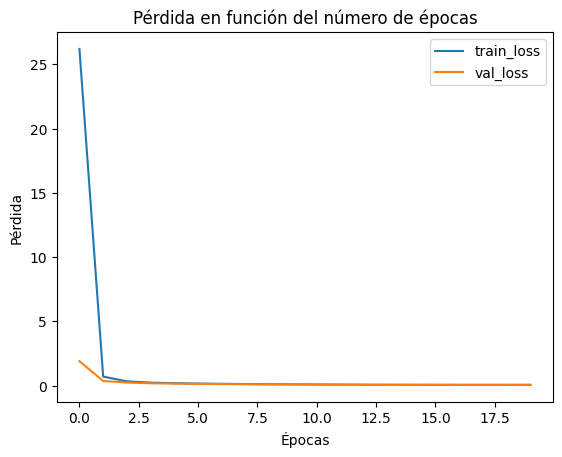

In [ ]:
# Plot the loss history
plt.plot(history2.history['loss'], label='train_loss')
plt.plot(history2.history['val_loss'], label='val_loss')
plt.title('Pérdida en función del número de épocas')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

Podemos ver que tal vez 100 epocas es demasiado, ya que la funcion de perdida (loss) se aplana (no mejora) despues de las primeras 15 o 20 epocas.

### Carga del modelo guardado y predicción:
Finalmente, se carga el modelo guardado y se realizan las predicciones para los datos de entrenamiento, validación y prueba.

In [ ]:
model2 = load_model('/content/gdrive/MyDrive/IA Energias Renovables | UniAndes/Notebooks/Sesion 3b (Mar, 9, 2023)/model2.keras')

In [ ]:
train_predictions = model2.predict(X_train).flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train})
train_results

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Train Predictions,Actuals
0,15.583094,16.362
1,15.937739,16.383
2,15.849144,16.161
3,15.730602,15.691
4,15.223042,15.328
...,...,...
5995,2.602574,2.071
5996,2.392542,3.466
5997,4.966379,5.257
5998,7.029740,7.213


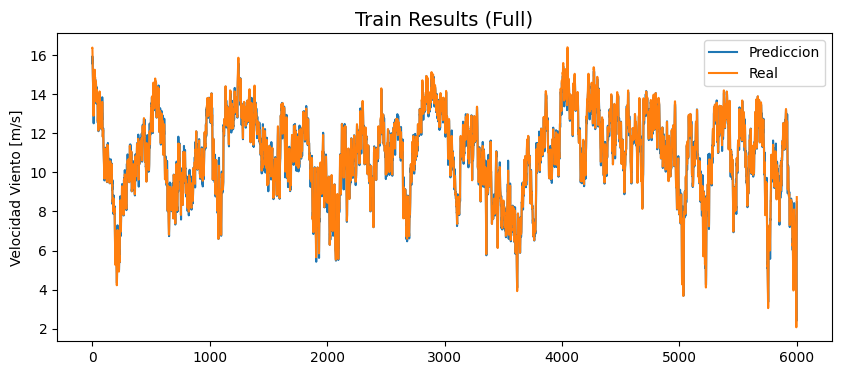

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Train Results (Full)', fontsize = 14)
plt.plot(train_results['Train Predictions'], label = 'Prediccion')
plt.plot(train_results['Actuals'], label = 'Real')
plt.ylabel('Velocidad Viento [m/s]')
plt.legend()

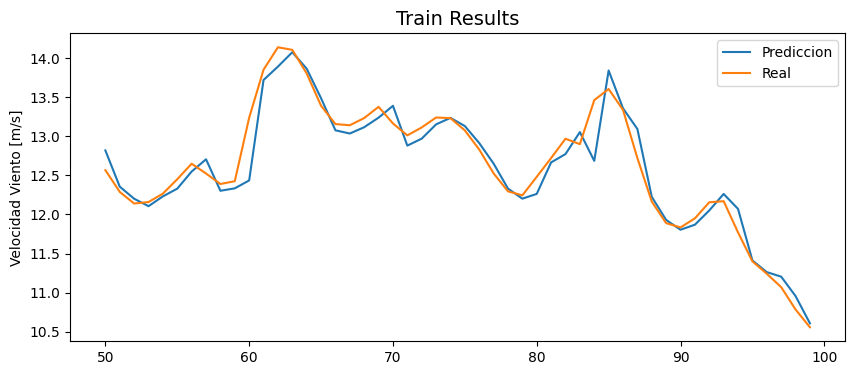

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Train Results', fontsize = 14)
plt.plot(train_results['Train Predictions'][50:100], label = 'Prediccion')
plt.plot(train_results['Actuals'][50:100], label = 'Real')
plt.ylabel('Velocidad Viento [m/s]')
plt.legend()

In [ ]:
test_predictions = model2.predict(X_test).flatten()
test_results = pd.DataFrame(data={'Test Predictions':test_predictions, 'Actuals':y_test})
test_results

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Test Predictions,Actuals
0,9.402132,9.441
1,9.509519,9.397
2,9.001693,9.256
3,9.075424,9.232
4,9.144304,9.273
...,...,...
1995,7.563445,7.876
1996,7.967356,7.969
1997,7.907767,7.981
1998,7.883216,7.940


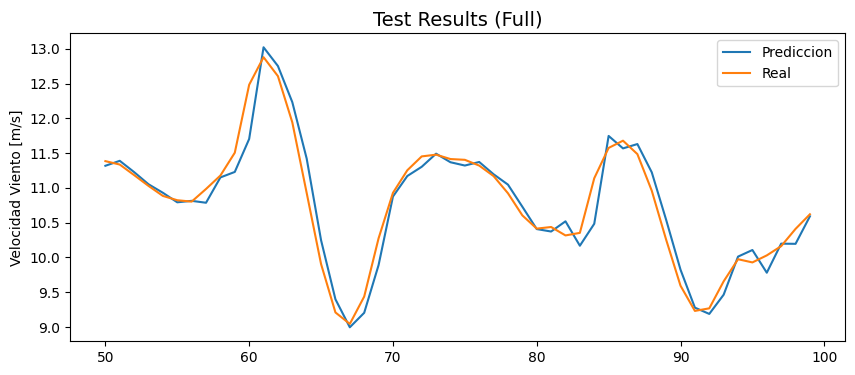

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Test Results (Full)', fontsize = 14)
plt.plot(test_results['Test Predictions'][50:100], label = 'Prediccion')
plt.plot(test_results['Actuals'][50:100], label = 'Real')
plt.ylabel('Velocidad Viento [m/s]')
plt.legend()

In [ ]:
val_predictions = model2.predict(X_val).flatten()
val_results = pd.DataFrame(data={'Val Predictions':val_predictions, 'Actuals':y_val})
val_results

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,Val Predictions,Actuals
0,8.085390,8.340
1,8.500603,8.339
2,8.128141,8.146
3,7.925739,8.066
4,8.014725,8.395
...,...,...
731,7.445968,7.554
732,7.747753,7.904
733,8.221753,8.601
734,9.117273,9.193


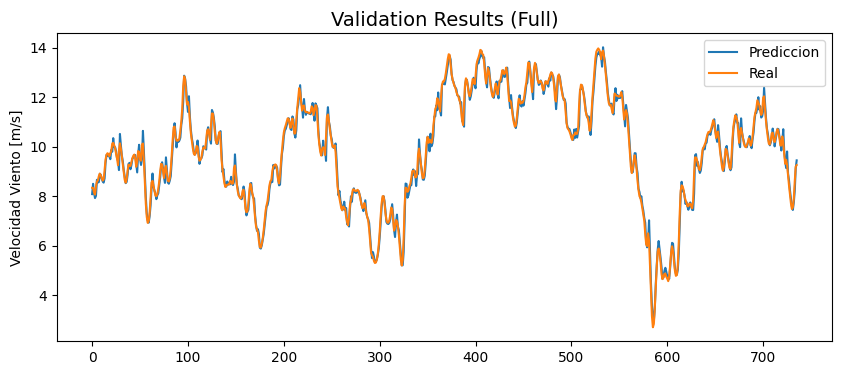

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Validation Results (Full)', fontsize = 14)
plt.plot(val_results['Val Predictions'], label = 'Prediccion')
plt.plot(val_results['Actuals'], label = 'Real')
plt.ylabel('Velocidad Viento [m/s]')
plt.legend()

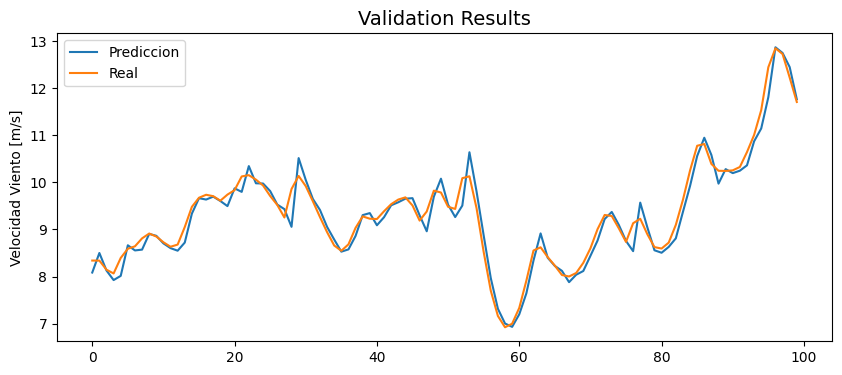

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Validation Results', fontsize = 14)
plt.plot(val_results['Val Predictions'][:100], label = 'Prediccion')
plt.plot(val_results['Actuals'][:100], label = 'Real')
plt.ylabel('Velocidad Viento [m/s]')
plt.legend()

---

In [ ]:
# Calculate RMSE and MSE for train, validation and test datasets
train_loss, train_rmse = model2.evaluate(X_train, y_train, verbose=0)
val_loss, val_rmse = model2.evaluate(X_val, y_val, verbose=0)
test_loss, test_rmse = model2.evaluate(X_test, y_test, verbose=0)

In [ ]:
print(f'Train RMSE: {train_rmse:.2f}')
print(f'Train MSE: {train_loss:.2f}')
print(f'Validation RMSE: {val_rmse:.2f}')
print(f'Validation MSE: {val_loss:.2f}')
print(f'Test RMSE: {test_rmse:.2f}')
print(f'Test MSE: {test_loss:.2f}')

Train RMSE: 0.22
Train MSE: 0.05
Validation RMSE: 0.21
Validation MSE: 0.05
Test RMSE: 0.27
Test MSE: 0.07


---


Prediccion

In [ ]:
diasPrediccion = 100

In [ ]:
# Make predictions
preds = []
last_window = X[-1]
for i in range(diasPrediccion):
    next_pred = model2.predict(last_window.reshape((1, window_size, 1)))[0][0]
    preds.append(next_pred)
    last_window = np.vstack((last_window[1:], next_pred))

# Create a pandas dataframe with the predictions and the corresponding dates
index = pd.date_range(start=windData.index[-1], periods=diasPrediccion+1, freq='H')[1:]
preds_df = pd.DataFrame({'Predictions': preds}, index=index)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━

<ipython-input-62-1c271738346d>:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  index = pd.date_range(start=windData.index[-1], periods=diasPrediccion+1, freq='H')[1:]


In [ ]:
# Concatenate the original time series data with the predictions
full_data = pd.concat([windData['wind_speed'], preds_df])

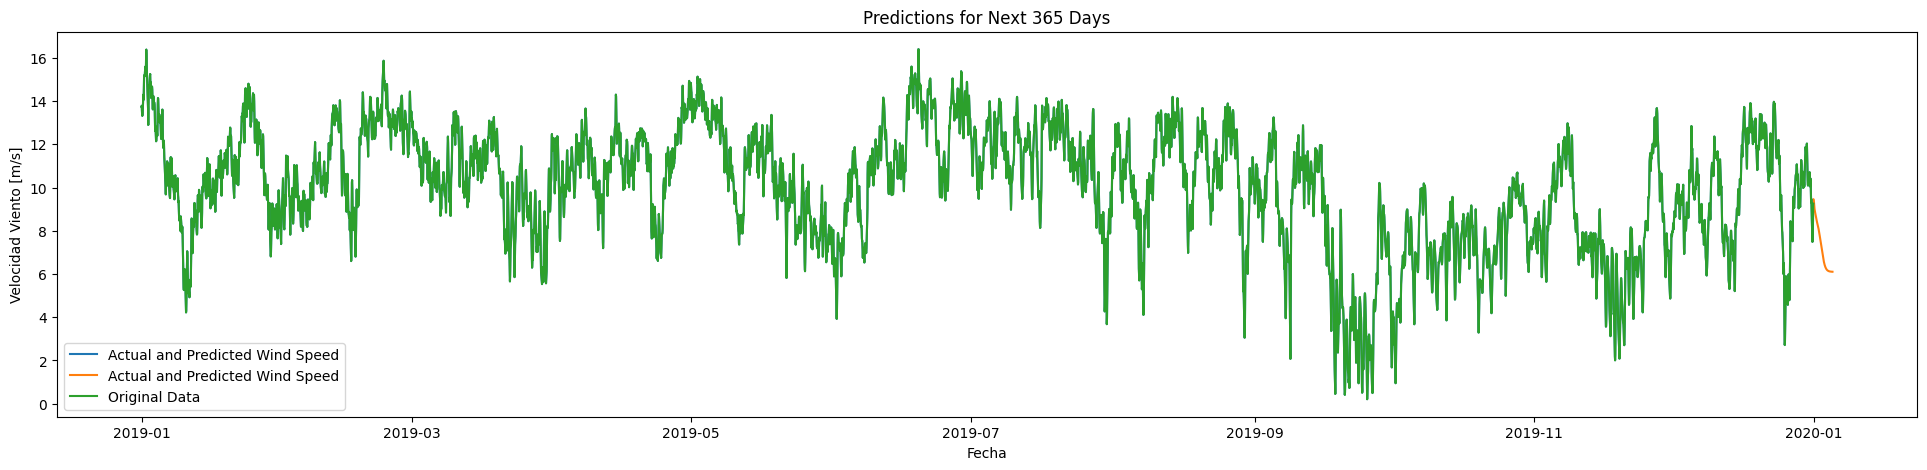

In [ ]:
# Plot the results
plt.figure(figsize=(24,5))
plt.plot(full_data.index, full_data, label='Actual and Predicted Wind Speed')
plt.plot(windData.index, windData['wind_speed'], label='Original Data')
plt.xlabel('Fecha')
plt.ylabel('Velocidad Viento [m/s]')
plt.title('Predictions for Next 365 Days')
plt.legend()
plt.show()

---

Volvemos a repetir el ejercicio, pero en vez de tomar 24 horas del dia, tomamos los valores de un mes 720 mediciones (24*30).

Para esto, modificamos la tamano de la ventana a 720

In [ ]:
window_size = 720

In [ ]:
X, y = df_X_y(windData['wind_speed'], window_size)

Mantenemos la division en el set de prueba (6000), entrenamiento (2000) y validacion (760)

In [ ]:
X_train, y_train = X[:6000], y[:6000]
X_test, y_test = X[6000:8000], y[6000:8000]
X_val, y_val = X[8000:], y[8000:]

---

### Definición un nuevo modelo LSTM:


In [ ]:
model3 = Sequential()
model3.add(InputLayer((window_size, 1)))
model3.add(LSTM(64))
model3.add(Dense(8, 'relu'))
model3.add(Dense(1, 'linear'))

In [ ]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

### Compilación del modelo y entrenamiento:
Se compila el modelo definiendo la función de pérdida, el optimizador y las métricas. Luego se entrena el modelo utilizando los datos de entrenamiento y validación.

In [ ]:
cp3 = ModelCheckpoint('/content/gdrive/MyDrive/IA Energias Renovables | UniAndes/Notebooks/Sesion 3b (Mar, 9, 2023)/model3.keras', save_best_only=True)
model3.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.001), metrics=[RootMeanSquaredError()])

In [ ]:
# Fit the model
with tf.device('/device:GPU:0'):  # Specify the GPU device to use
    history3 = model3.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, callbacks=[cp3])

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 50.5394 - root_mean_squared_error: 6.8526 - val_loss: 0.2724 - val_root_mean_squared_error: 0.5219
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.4849 - root_mean_squared_error: 0.6947 - val_loss: 0.1577 - val_root_mean_squared_error: 0.3972
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.2507 - root_mean_squared_error: 0.5002 - val_loss: 0.1153 - val_root_mean_squared_error: 0.3396
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.1536 - root_mean_squared_error: 0.3918 - val_loss: 0.1081 - val_root_mean_squared_error: 0.3288
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.1198 - root_mean_squared_error: 0.3461 - val_loss: 0.0775 - val_root_mean_squared_error: 0.2783
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0940 - root_mean_squared_error: 0.3065 - val_loss: 0.1084 - val_root_mean_squared_error: 0.3293
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 23

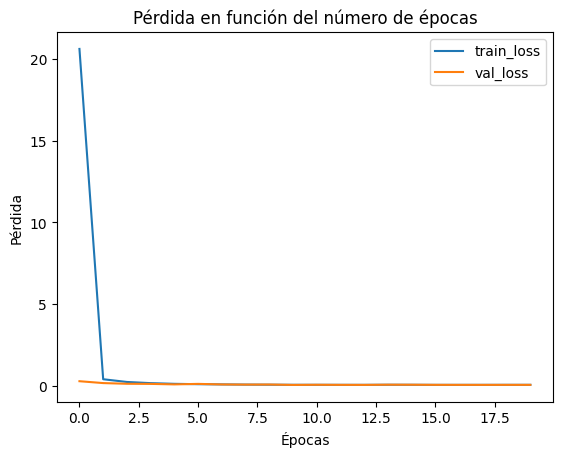

In [ ]:
# Plot the loss history
plt.plot(history3.history['loss'], label='train_loss')
plt.plot(history3.history['val_loss'], label='val_loss')
plt.title('Pérdida en función del número de épocas')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

### Carga del modelo guardado y predicción:
Finalmente, se carga el modelo guardado y se realizan las predicciones para los datos de entrenamiento, validación y prueba.

In [ ]:
model3 = load_model('/content/gdrive/MyDrive/IA Energias Renovables | UniAndes/Notebooks/Sesion 3b (Mar, 9, 2023)/model3.keras')

In [ ]:
train_predictions = model3.predict(X_train).flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train})
train_results

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


,Train Predictions,Actuals
0,9.557860,9.528
1,9.250816,9.130
2,8.789648,8.921
3,8.839561,8.772
4,8.668234,8.569
...,...,...
5995,8.812417,9.013
5996,9.280637,9.453
5997,9.738846,9.911
5998,10.131660,10.187


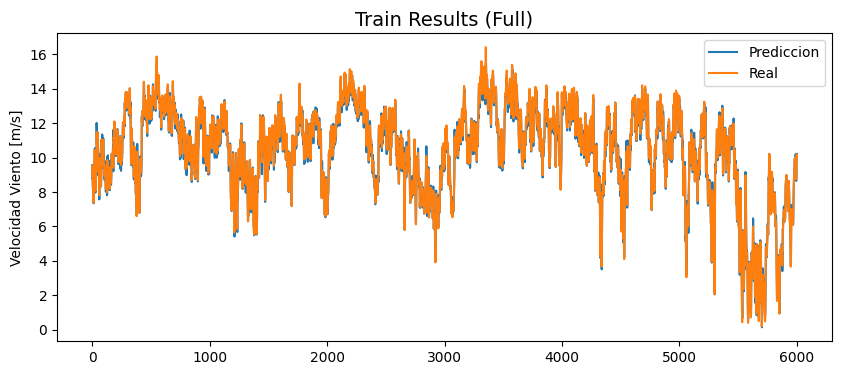

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Train Results (Full)', fontsize = 14)
plt.plot(train_results['Train Predictions'], label = 'Prediccion')
plt.plot(train_results['Actuals'], label = 'Real')
plt.ylabel('Velocidad Viento [m/s]')
plt.legend()

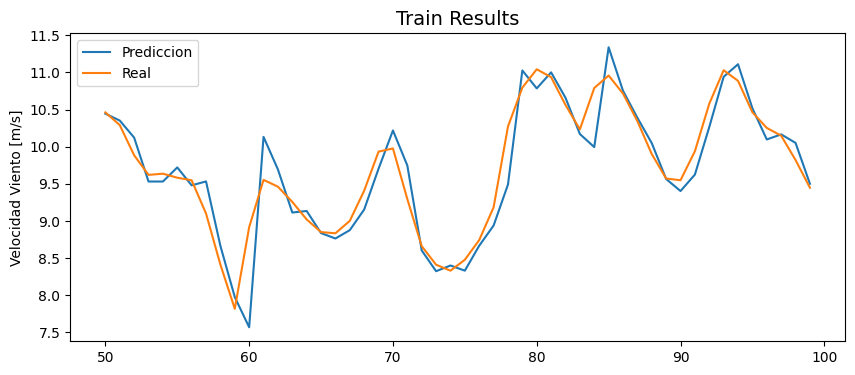

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Train Results', fontsize = 14)
plt.plot(train_results['Train Predictions'][50:100], label = 'Prediccion')
plt.plot(train_results['Actuals'][50:100], label = 'Real')
plt.ylabel('Velocidad Viento [m/s]')
plt.legend()

In [ ]:
test_predictions = model3.predict(X_test).flatten()
test_results = pd.DataFrame(data={'Test Predictions':test_predictions, 'Actuals':y_test})
test_results

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


,Test Predictions,Actuals
0,9.730784,10.004
1,10.004716,10.033
2,9.994304,10.103
3,10.093693,10.098
4,10.006015,10.056
...,...,...
1995,11.008136,11.209
1996,11.326850,11.396
1997,11.324453,11.569
1998,11.573867,11.874


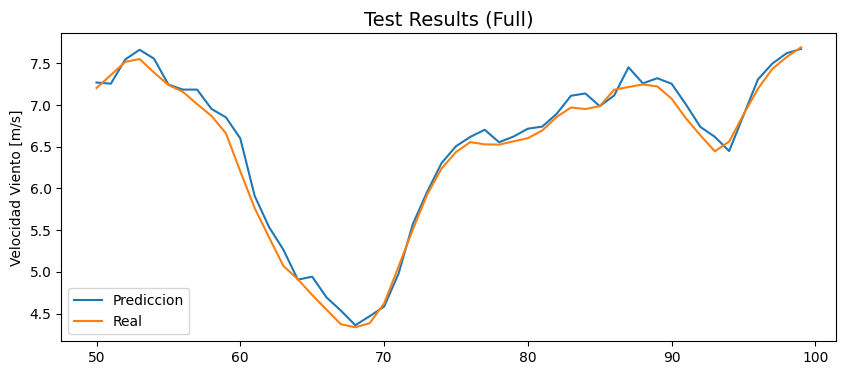

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Test Results (Full)', fontsize = 14)
plt.plot(test_results['Test Predictions'][50:100], label = 'Prediccion')
plt.plot(test_results['Actuals'][50:100], label = 'Real')
plt.ylabel('Velocidad Viento [m/s]')
plt.legend()

In [ ]:
val_predictions = model3.predict(X_val).flatten()
val_results = pd.DataFrame(data={'Val Predictions':val_predictions, 'Actuals':y_val})
val_results

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


,Val Predictions,Actuals
0,11.465847,11.675
1,11.564387,11.442
2,11.156689,11.280
3,11.155245,11.369
4,11.417288,11.972
5,12.335588,12.033
6,11.736728,11.556
7,11.091784,11.029
8,10.678267,10.659
9,10.448004,10.347


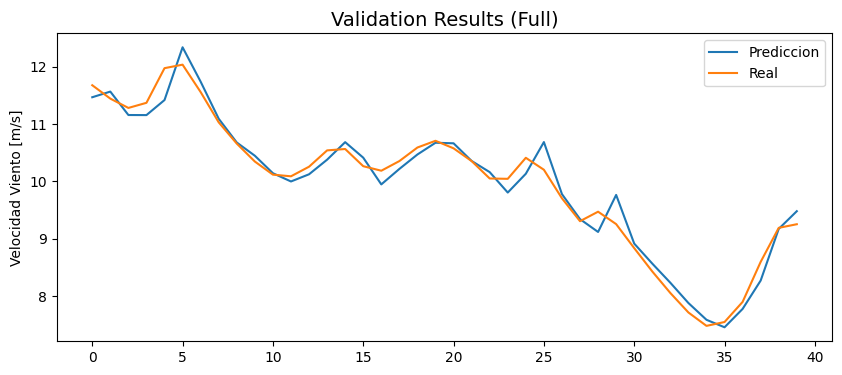

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Validation Results (Full)', fontsize = 14)
plt.plot(val_results['Val Predictions'], label = 'Prediccion')
plt.plot(val_results['Actuals'], label = 'Real')
plt.ylabel('Velocidad Viento [m/s]')
plt.legend()

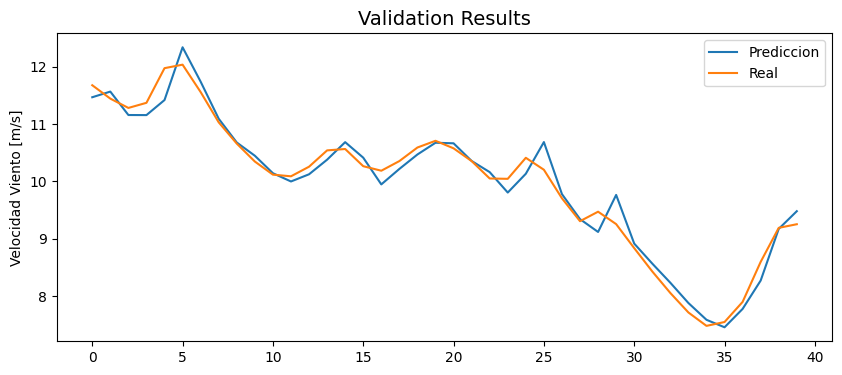

In [ ]:
plt.figure(figsize = [10, 4])
plt.title('Validation Results', fontsize = 14)
plt.plot(val_results['Val Predictions'][:100], label = 'Prediccion')
plt.plot(val_results['Actuals'][:100], label = 'Real')
plt.ylabel('Velocidad Viento [m/s]')
plt.legend()

---

In [ ]:
# Calculate RMSE and MSE for train, validation and test datasets
train_loss, train_rmse = model3.evaluate(X_train, y_train, verbose=0)
val_loss, val_rmse = model3.evaluate(X_val, y_val, verbose=0)
test_loss, test_rmse = model3.evaluate(X_test, y_test, verbose=0)

In [ ]:
print(f'Train RMSE: {train_rmse:.2f}')
print(f'Train MSE: {train_loss:.2f}')
print(f'Validation RMSE: {val_rmse:.2f}')
print(f'Validation MSE: {val_loss:.2f}')
print(f'Test RMSE: {test_rmse:.2f}')
print(f'Test MSE: {test_loss:.2f}')

Train RMSE: 0.23
Train MSE: 0.05
Validation RMSE: 0.21
Validation MSE: 0.04
Test RMSE: 0.19
Test MSE: 0.04


---


Prediccion

In [ ]:
diasPrediccion = 1000 # horas

In [ ]:
# Make predictions
preds = []
last_window = X[-1]
for i in range(diasPrediccion):
    next_pred = model3.predict(last_window.reshape((1, window_size, 1)))[0][0]
    preds.append(next_pred)
    last_window = np.vstack((last_window[1:], next_pred))

# Create a pandas dataframe with the predictions and the corresponding dates
index = pd.date_range(start=windData.index[-1], periods=diasPrediccion+1, freq='H')[1:]
preds_df = pd.DataFrame({'Predictions': preds}, index=index)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━

<ipython-input-85-e39df73f84a8>:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  index = pd.date_range(start=windData.index[-1], periods=diasPrediccion+1, freq='H')[1:]


In [ ]:
# Concatenate the original time series data with the predictions
full_data = pd.concat([windData['wind_speed'], preds_df])

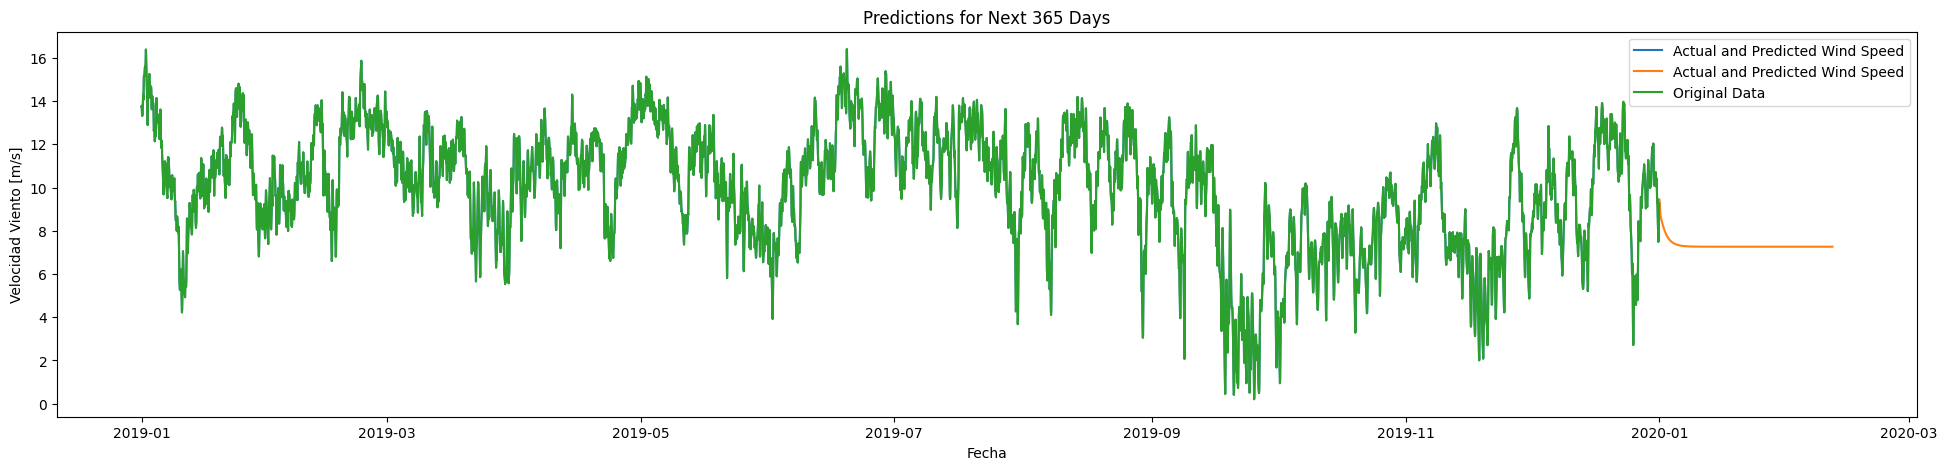

In [ ]:
# Plot the results
plt.figure(figsize=(24,5))
plt.plot(full_data.index, full_data, label='Actual and Predicted Wind Speed')
plt.plot(windData.index, windData['wind_speed'], label='Original Data')
plt.xlabel('Fecha')
plt.ylabel('Velocidad Viento [m/s]')
plt.title('Predictions for Next 365 Days')
plt.legend()
plt.show()

Como vemos, entonces al aumentar el numero de dias que utilizamos para entrenar el modelo, se mejora la prediccion.

Sin embargo, al aumentar la cantidad de datos, el tiempo de ejecucion es mucho mayor.


---

Vamos ahora a reducir el numero de datos, y vamos a tomar el promedio por dia y obtener un set de datos con 365 valores.

In [ ]:
windData = pd.read_csv('/content/gdrive/MyDrive/IA Energias Renovables | UniAndes/Notebooks/Sesion 3b (Mar, 9, 2023)/windGuajira2019.csv', skiprows = 3, index_col = 'time', parse_dates = True)
windData.drop(columns=['local_time', 'electricity'], inplace=True)
windData.head()

,wind_speed
time,
2019-01-01 00:00:00,13.742
2019-01-01 01:00:00,13.783
2019-01-01 02:00:00,13.515
2019-01-01 03:00:00,13.327
2019-01-01 04:00:00,13.341


In [ ]:
windData.shape

(8760, 1)

In [ ]:
# Resample the data by day and calculate the average wind speed per day
windData_daily = windData.resample('D').mean()
windData_daily.head()

,wind_speed
time,
2019-01-01,14.506792
2019-01-02,14.799500
2019-01-03,14.090792
2019-01-04,12.962042
2019-01-05,12.587417


In [ ]:
windData_daily.shape

(365, 1)

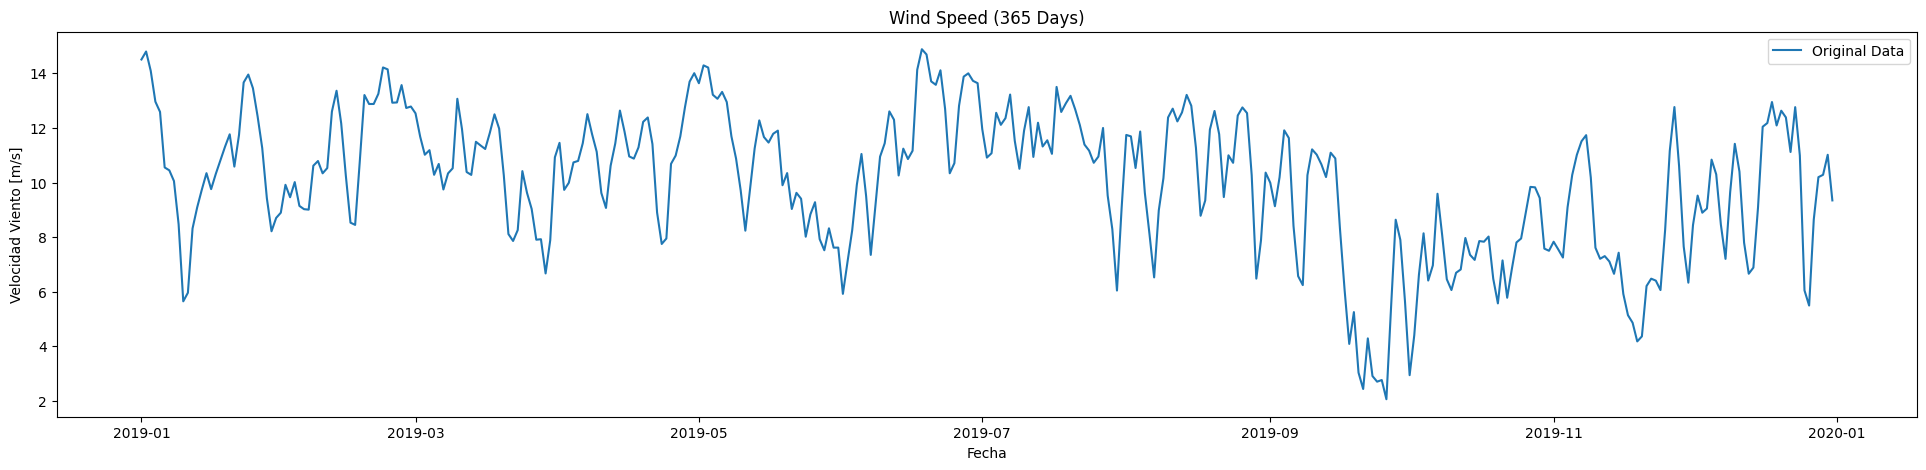

In [ ]:
# Plot the results
plt.figure(figsize=(24,5))
plt.plot(windData_daily.index, windData_daily['wind_speed'], label='Original Data')
plt.xlabel('Fecha')
plt.ylabel('Velocidad Viento [m/s]')
plt.title('Wind Speed (365 Days)')
plt.legend()
plt.show()

---

---

# Neural Prophet

In [ ]:
! pip install neuralprophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.8/145.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.3/819.3 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
from neuralprophet import NeuralProphet

Entrenamos el modelo de Neural Prophet:

Hyperparamter Tuning: https://neuralprophet.com/guides/hyperparameter-selection.html


In [ ]:
m = NeuralProphet(
    n_forecasts=30,
    n_lags=1,
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    )

Salvamos el modelo:

In [ ]:
!pip install pickle5

In [ ]:
import pickle

In [ ]:
# Guardar Modelo
with open('/content/gdrive/MyDrive/IA Energias Renovables | UniAndes/Notebooks/Sesion 3b (Mar, 9, 2023)/model5/neuralProphet.pkl', 'wb') as f:
    pickle.dump(m, f)

In [ ]:
# Leer modelo
with open('/content/gdrive/MyDrive/IA Energias Renovables | UniAndes/Notebooks/Sesion 3b (Mar, 9, 2023)/model5/neuralProphet.pkl', 'rb') as f:
    pickle.load(f)

Ejercicio:

Modificar los parametros del modlo para tener una mejor prediccion.

---

Fin de cuaderno